# SMA, MACD and Bollinger band signals: backtested

This is a reworked version of `Bollinger_MACD_SMA_Notebook.01`, which is
left unchanged for reference. The trading rules and their parameters are
the same as in .01 (SMA 30/100, MACD 12/26/9 with a 2.5% stop, Bollinger
20 days / 2 std). What changed is how they are evaluated:

- **Saved data, not a live download.** Prices come from the snapshot in
  `data/raw/` through `src.data.prices.load_prices`, sorted oldest-first and
  checked for gaps.
- **Fixed periods.** Results are reported separately for the train
  (2010-2017), validation (2018-2019) and test (2020 to Q1 2021) periods
  defined in `src.data.prices.SPLITS`. Nothing here is fitted, so the
  periods mainly show whether a result holds up over time.
- **No look-ahead.** A signal computed from a day's close is traded at the
  *next* day's close (`lag=1`).
- **Trading costs.** 10 basis points are charged on each buy and each sell.
- **A benchmark.** Every rule is compared with simply buying and holding.
- **The MACD stop-loss now works.** In .01 its conditions could never be
  reached, so the 2.5% `risk` setting had no effect.

The code for the indicators, rules and backtest lives in `src/` and is
covered by `tests/test_backtest.py`, including a test that changing future
prices never changes past trades.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Make the repo root importable, wherever the notebook is started from.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "setup.py").exists())
sys.path.insert(0, str(ROOT))

from src.data.prices import SPLITS, load_prices, period
from src.evaluation.backtest import backtest, evaluate
from src.features.build_features import bollinger, macd, sma
from src.models import indicator_strategies as rules

pd.set_option("display.precision", 3)
pd.set_option("display.width", 120)

## Data

Daily AAPL prices from Yahoo Finance, saved in Feb 2023. Signals and
returns both use **Adj Close**, which is adjusted for splits and
dividends, so a dividend doesn't show up as a price drop.

In [2]:
prices = load_prices("AAPL")
close = prices["Adj Close"]

pd.DataFrame({
    name: {"start": period(close, name).index.min().date(),
           "end": period(close, name).index.max().date(),
           "trading days": len(period(close, name))}
    for name in SPLITS
}).T

,start,end,trading days
train,2010-01-04,2017-12-29,2013
validation,2018-01-02,2019-12-31,503
test,2020-01-02,2021-03-30,313


## Rules

Each rule produces 1 (hold the stock) or 0 (hold cash) for every day,
using only prices up to that day:

- **SMA 30/100:** hold while the 30-day average is above the 100-day average.
- **MACD:** hold while the MACD line is above its signal line.
- **MACD + stop:** the same, but also sell if the price falls 2.5% below the
  entry price or 2.5% in one day. After a stop, wait for a fresh crossover
  before buying again.
- **Bollinger:** buy when the price closes below the lower band, sell when it
  closes above the upper band.

In [3]:
STRATEGIES = {
    "buy_and_hold": rules.buy_and_hold(close),
    "sma_30_100": rules.sma_crossover(close, 30, 100),
    "macd": rules.macd_crossover(close),
    "macd_stop": rules.macd_crossover(close, stop=0.025),
    "bollinger": rules.bollinger_reversion(close, 20, 2.0),
}


def run_all(close, strategies, lag=1, cost_bps=10):
    return {name: backtest(close, state, lag=lag, cost_bps=cost_bps)
            for name, state in strategies.items()}


results = run_all(close, STRATEGIES)

## Results

Trades at the next day's close, with 10 bp costs. Sharpe ratios assume a
0% risk-free rate. `trades` counts entries in the period; a position already
open when a period starts counts as one trade.

In [4]:
table = evaluate(results)
table.style.format({
    "total_return": "{:.1%}", "cagr": "{:.1%}", "ann_vol": "{:.1%}",
    "sharpe": "{:.2f}", "max_drawdown": "{:.1%}", "exposure": "{:.0%}",
    "trades": "{:.0f}", "win_rate": "{:.0%}",
})

### How much do the timing and cost assumptions matter?

Total return per period under three settings. "Same-day, free" is roughly
what .01 implicitly assumed: trading at the exact close that produced the
signal, with no costs.

In [5]:
settings = {
    "next day, 10bp": dict(lag=1, cost_bps=10),
    "next day, free": dict(lag=1, cost_bps=0),
    "same day, free": dict(lag=0, cost_bps=0),
}
sensitivity = pd.concat(
    {label: evaluate(run_all(close, STRATEGIES, **kw))["total_return"]
     for label, kw in settings.items()},
    axis=1,
)
sensitivity.style.format("{:.1%}")

## Charts: test period

Triangles mark the day each trade is actually made (the day after the
signal). A position carried in from 2019 has no marker.

In [6]:
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
BUY, SELL = "#1baf7a", "#e34948"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED,
    "axes.titlesize": 11, "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 9,
    "legend.frameon": False, "lines.linewidth": 1.5,
})

test_start, test_end = SPLITS["test"]


def test_slice(series):
    return series.loc[test_start:test_end]


def plot_trades(ax, name):
    change = test_slice(results[name]["position"].diff())
    px = test_slice(close)
    ax.plot(px, color=INK, linewidth=1, label="AAPL (Adj Close)")
    ax.scatter(px.index[change > 0], px[change > 0], marker="^", s=60,
               color=BUY, edgecolor="white", linewidth=1, zorder=3,
               label="buy")
    ax.scatter(px.index[change < 0], px[change < 0], marker="v", s=60,
               color=SELL, edgecolor="white", linewidth=1, zorder=3,
               label="sell")
    ax.set_ylabel("Price (USD)")

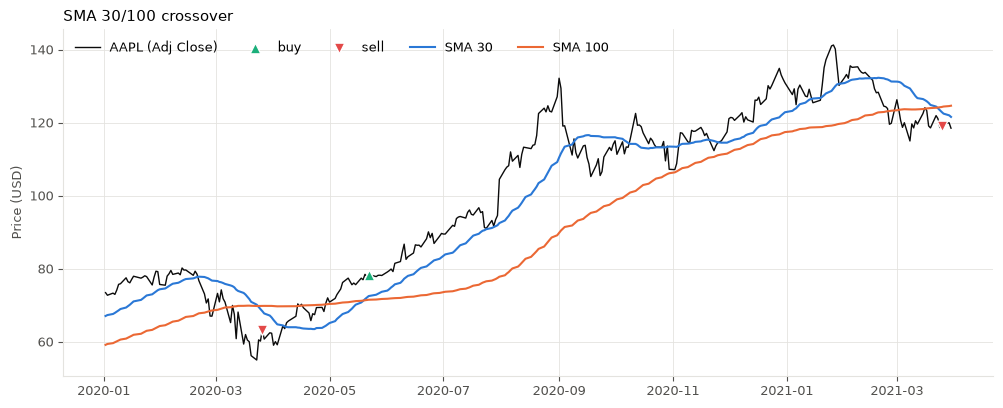

In [7]:
fig, ax = plt.subplots(figsize=(12, 4.5))
plot_trades(ax, "sma_30_100")
ax.plot(test_slice(sma(close, 30)), color=SERIES[0], label="SMA 30")
ax.plot(test_slice(sma(close, 100)), color=SERIES[1], label="SMA 100")
ax.set_title("SMA 30/100 crossover")
ax.legend(loc="upper left", ncol=5)
plt.show()

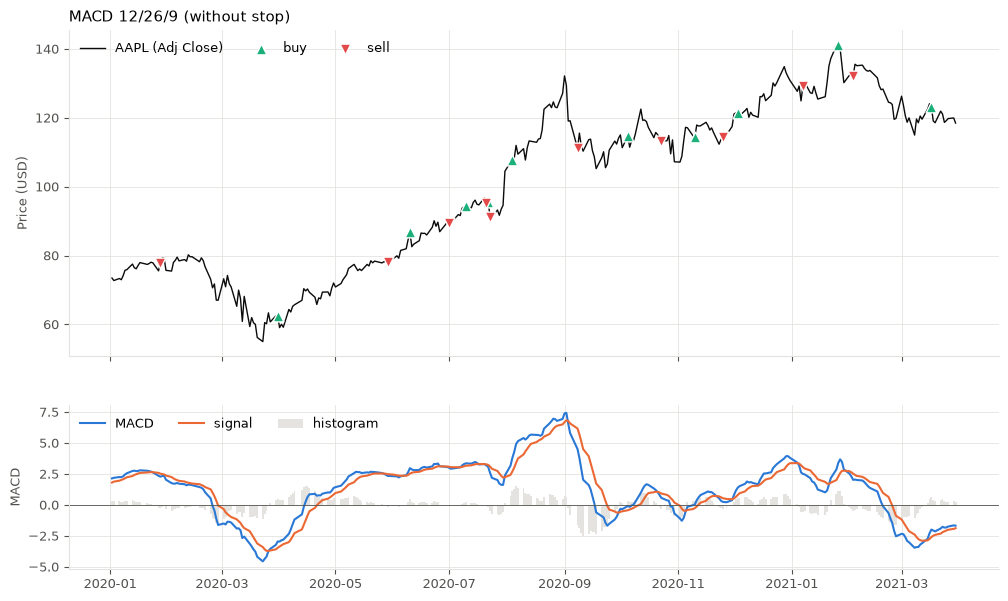

In [8]:
m = test_slice(macd(close))
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 7), sharex=True, height_ratios=[2, 1])
plot_trades(ax1, "macd")
ax1.set_title("MACD 12/26/9 (without stop)")
ax1.legend(loc="upper left", ncol=3)
ax2.bar(m.index, m["hist"], width=1, color=GRID, label="histogram")
ax2.plot(m["macd"], color=SERIES[0], label="MACD")
ax2.plot(m["signal"], color=SERIES[1], label="signal")
ax2.axhline(0, color=MUTED, linewidth=0.6)
ax2.set_ylabel("MACD")
ax2.legend(loc="upper left", ncol=3)
plt.show()

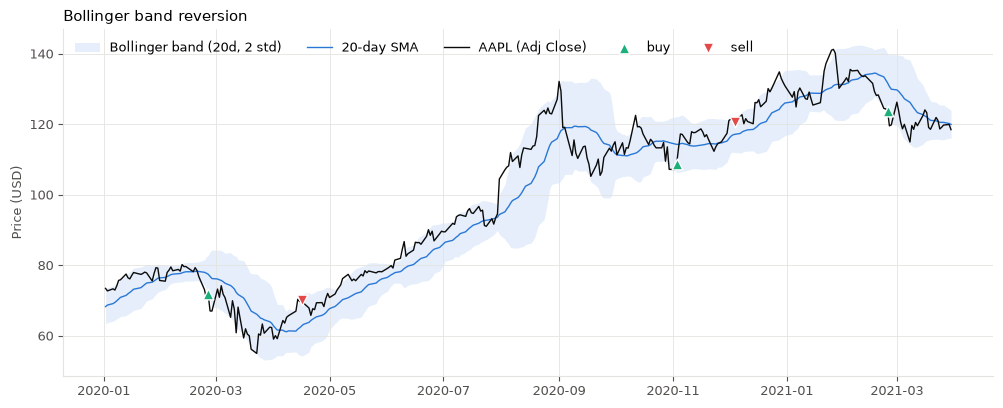

In [9]:
bands = test_slice(bollinger(close, 20, 2.0))
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.fill_between(bands.index, bands["lower"], bands["upper"],
                color=SERIES[0], alpha=0.12, linewidth=0,
                label="Bollinger band (20d, 2 std)")
ax.plot(bands["middle"], color=SERIES[0], linewidth=1, label="20-day SMA")
plot_trades(ax, "bollinger")
ax.set_title("Bollinger band reversion")
ax.legend(loc="upper left", ncol=5)
plt.show()

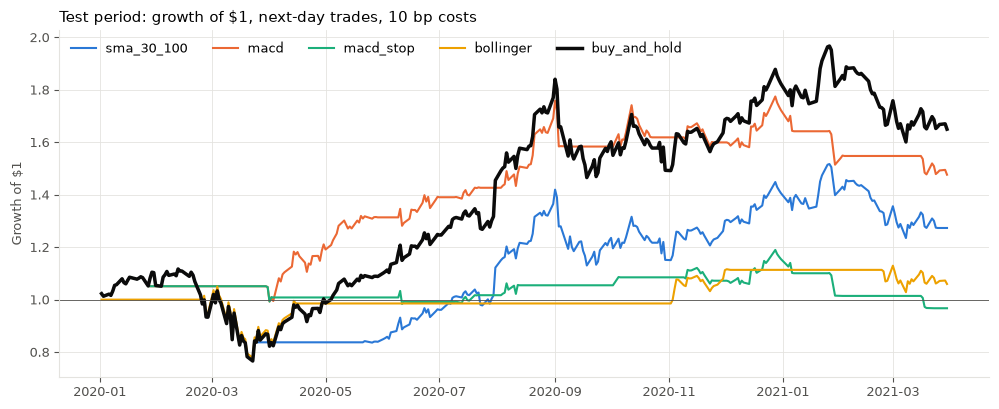

In [10]:
fig, ax = plt.subplots(figsize=(12, 4.5))
for name, color in zip(["sma_30_100", "macd", "macd_stop", "bollinger"],
                       SERIES):
    ret = test_slice(results[name]["ret"])
    ax.plot((1 + ret).cumprod(), color=color, label=name)
bh = test_slice(results["buy_and_hold"]["ret"])
ax.plot((1 + bh).cumprod(), color=INK, linewidth=2.5, label="buy_and_hold")
ax.axhline(1, color=MUTED, linewidth=0.6)
ax.set_ylabel("Growth of $1")
ax.set_title("Test period: growth of $1, next-day trades, 10 bp costs")
ax.legend(loc="upper left", ncol=5)
plt.show()

## Second stock: MSFT

The same rules on the MSFT snapshot. It only starts in 2017, so the
"train" row covers 2017 alone.

In [11]:
msft = load_prices("MSFT")["Adj Close"]
msft_strategies = {
    "buy_and_hold": rules.buy_and_hold(msft),
    "sma_30_100": rules.sma_crossover(msft, 30, 100),
    "macd": rules.macd_crossover(msft),
    "macd_stop": rules.macd_crossover(msft, stop=0.025),
    "bollinger": rules.bollinger_reversion(msft, 20, 2.0),
}
evaluate(run_all(msft, msft_strategies)).style.format({
    "total_return": "{:.1%}", "cagr": "{:.1%}", "ann_vol": "{:.1%}",
    "sharpe": "{:.2f}", "max_drawdown": "{:.1%}", "exposure": "{:.0%}",
    "trades": "{:.0f}", "win_rate": "{:.0%}",
})

## What the results support

- **No rule beat buy-and-hold on total return** in any period, for either
  stock. Mostly this is because the rules spend a lot of time in cash while
  both stocks rose strongly.
- **The rules do lower risk.** Volatility and the worst drawdown are usually
  smaller than buy-and-hold's, which is expected when you're only invested
  part of the time.
- **MACD on AAPL in the test period** has a higher Sharpe ratio than
  buy-and-hold (1.39 vs 1.13). That shouldn't be read as an edge: MACD
  trailed buy-and-hold in both earlier periods, it does worse than
  buy-and-hold on MSFT in the same test period, and it rests on 11 trades
  in 15 months.
- **The 2.5% stop-loss hurts.** On AAPL it turns the test period into a
  small loss; daily moves of 2.5% are common for this stock, so the stop
  fires often and then waits for a new crossover.
- **Trade timing matters.** Trading at the same close as the signal, with no
  costs, makes MACD look much better (AAPL validation: about 51% instead of
  22%). That gap is the kind of optimism the .01 approach built in.

## Caveats

- AAPL and MSFT were chosen with hindsight; both were among the best
  performing large stocks of the decade. That makes buy-and-hold a tough
  benchmark, and the results may not carry over to other stocks.
- The test period is only 15 months and includes the unusual COVID crash
  and rebound. With a handful of trades per period, none of these
  differences is statistically meaningful.
- The backtest is long-only, uses daily closing prices, assumes trades fill
  at the close, ignores taxes and assumes cash earns no interest.